# Anemia Risk prediction

## 0. Load and clean data

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

sns.set_style("whitegrid")

df = pd.read_csv("data/CBC data_for_meandeley_csv.csv")

# Cleaning columns
df.columns = df.columns.str.strip()
df = df.rename(columns={"Sex  ": "Sex", "HGB ": "HGB", "Age      ": "Age"})

# mapping- 0 = Male, 1 = Female
df["Sex_label"] = df["Sex"].map({0: "Male", 1: "Female"})
df["Sex"] = df["Sex"].astype("Int64")

In [77]:
#  WHO-based anemia severity

df["HGB"] = pd.to_numeric(df["HGB"], errors="coerce")
df["Sex"] = pd.to_numeric(df["Sex"], errors="coerce")

# Convert
hgb = df["HGB"].to_numpy()
sex = df["Sex"].to_numpy()

status = np.full(len(df), "unknown", dtype=object)


# Male (0)
male_mask = sex == 0
h = hgb[male_mask]

status[male_mask] = np.where(
    h >= 13.0, "no_anemia",
    np.where(
        h >= 11.0, "mild",
        np.where(h >= 8.0, "moderate", "severe")
    )
)


# Female (1)
female_mask = sex == 1
h = hgb[female_mask]

status[female_mask] = np.where(
    h >= 12.0, "no_anemia",
    np.where(
        h >= 11.0, "mild",
        np.where(h >= 8.0, "moderate", "severe")
    )
)

df["anemia_status"] = status

In [78]:
df = df[df["anemia_status"] != "unknown"].copy()

print(df["anemia_status"].value_counts())

anemia_status
no_anemia    156
mild         100
moderate      92
severe        16
Name: count, dtype: int64


##  1. EDA + Plots

C:\Users\Adminn\AppData\Local\Temp\ipykernel_7472\765078363.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Sex")


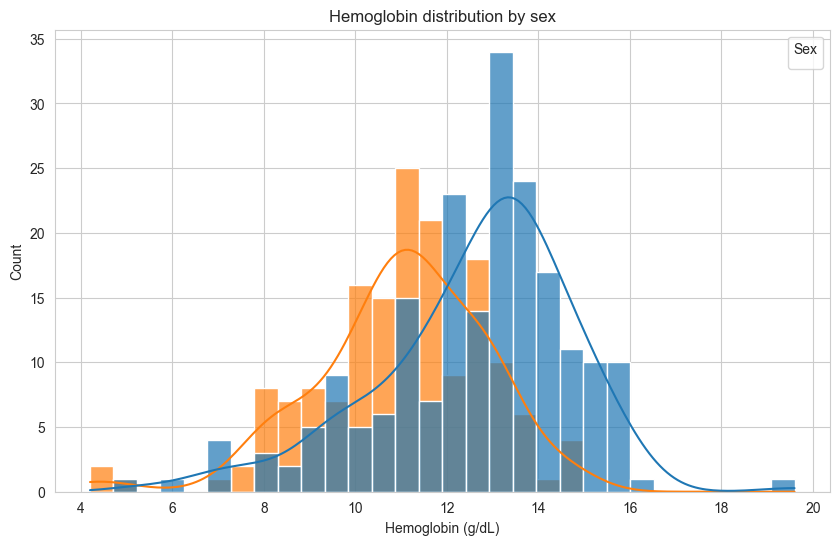

In [79]:
# Hemoglobin distribution by sex

plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="HGB",
    hue="Sex_label",
    bins=30,
    alpha=0.7,
    kde=True
)
plt.title("Hemoglobin distribution by sex")
plt.xlabel("Hemoglobin (g/dL)")
plt.legend(title="Sex")
plt.show()

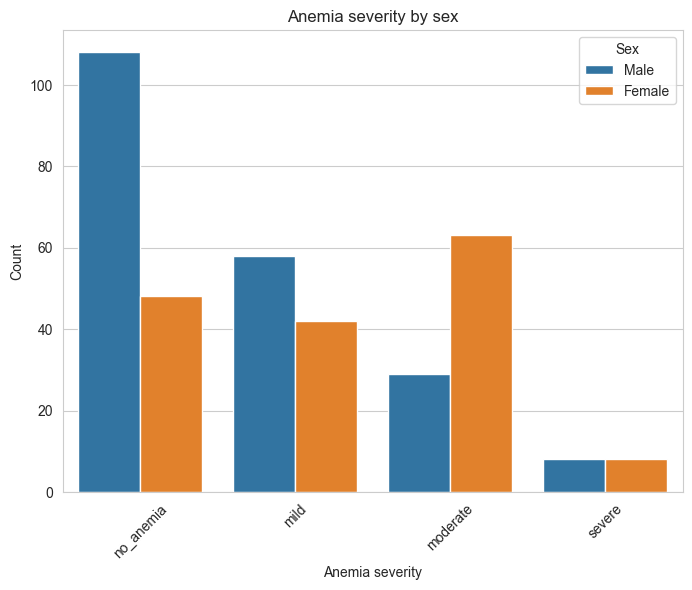

In [80]:
# Anemia severity distribution

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x="anemia_status", hue="Sex_label", order=["no_anemia", "mild", "moderate", "severe"])
plt.title("Anemia severity by sex")
plt.xlabel("Anemia severity")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Sex")
plt.show()

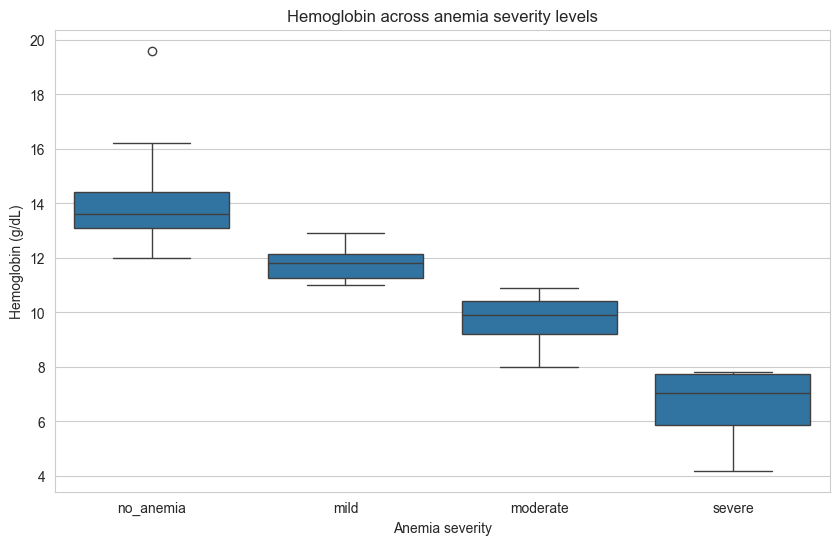

In [81]:
# Hemoglobin by anemia severity

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="anemia_status",
    y="HGB",
    order=["no_anemia", "mild", "moderate", "severe"]
)
plt.title("Hemoglobin across anemia severity levels")
plt.xlabel("Anemia severity")
plt.ylabel("Hemoglobin (g/dL)")
plt.show()

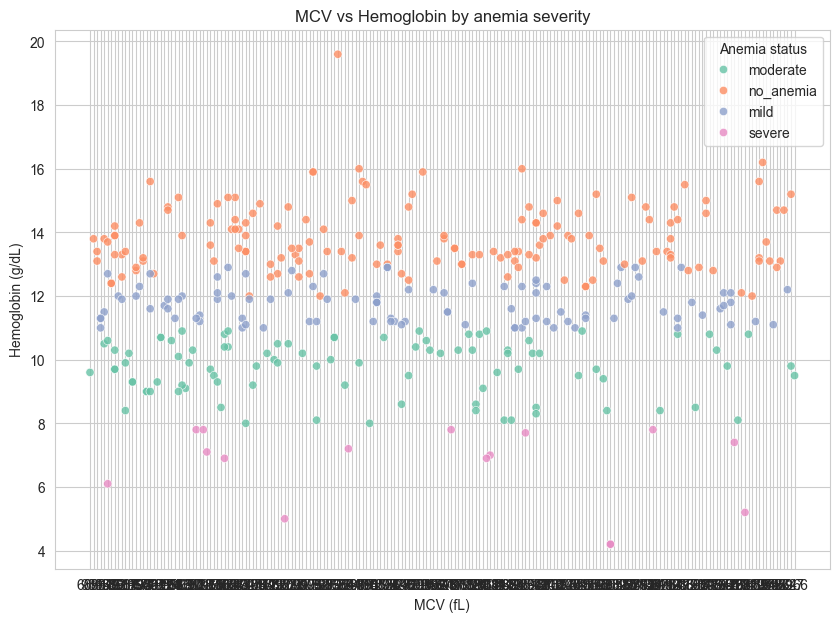

In [82]:
# MCV vs HGB by anemia status
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x="MCV",
    y="HGB",
    hue="anemia_status",
    palette="Set2",
    alpha=0.8
)
plt.title("MCV vs Hemoglobin by anemia severity")
plt.xlabel("MCV (fL)")
plt.ylabel("Hemoglobin (g/dL)")
plt.legend(title="Anemia status")
plt.show()

##  Anemia severity distribution

The dataset contains:
- no_anemia: 156 individuals
- mild: 100
- moderate: 92
- severe: 16

Severe anemia is rare (≈4.5% of non‑unknown cases), indicating class imbalance. Any classifier must be evaluated with metrics like precision, recall, and F1‑score per class, not just accuracy.

## 2. Feature engineering

In [83]:
# Microcytic / normocytic / macrocytic flag (from MCV)
df.columns = df.columns.str.strip()

df["HGB"] = pd.to_numeric(df["HGB"], errors="coerce")
df["MCV"] = pd.to_numeric(df["MCV"], errors="coerce")

In [84]:
# MCV‑based numeric feature
m = df["MCV"]

df["mcv_class"] = np.select(
    [
        m < 80,
        m < 100
    ],
    [
        "microcytic",
        "normocytic"
    ],
    default="macrocytic"
)

df["is_microcytic"] = (m < 80).astype("Int64")
df["is_macrocytic"] = (m > 100).astype("Int64")



In [85]:
# Diet‑risk
hgb = df["HGB"]
m = df["MCV"]

risk_score = pd.Series(np.nan, index=df.index)


risk_score.loc[hgb < 8.0] = 5
risk_score.loc[(hgb >= 8.0) & (hgb < 10.0)] = 4
risk_score.loc[(hgb >= 10.0) & (hgb < 11.0)] = 3
risk_score.loc[(hgb >= 11.0) & (hgb < 12.0)] = 2
risk_score.loc[hgb >= 12.0] = 1


micro = m < 80
risk_score.loc[micro] = risk_score.loc[micro].clip(upper=4) + 1

risk_score = risk_score.clip(upper=5)

df["diet_risk"] = risk_score.astype("Int64")

In [86]:
df["HGB_float"] = df["HGB"]
df["MCV_float"] = df["MCV"]

print("\nSample of engineered features:")
print(df[[
    "Age", "Sex", "HGB", "MCV",
    "mcv_class",
    "is_microcytic", "is_macrocytic",
    "diet_risk", "anemia_status"
]].head())


Sample of engineered features:
    Age  Sex   HGB   MCV   mcv_class  is_microcytic  is_macrocytic  diet_risk  \
1  28.0    0   9.6  60.1  microcytic              1              0          5   
2  41.0    0  13.8  93.1  normocytic              0              0          1   
3  40.0    1  13.4  89.5  normocytic              0              0          1   
4  76.0    0  11.3  86.6  normocytic              0              0          2   
5  20.0    1  11.5  89.1  normocytic              0              0          2   

  anemia_status  
1      moderate  
2     no_anemia  
3     no_anemia  
4          mild  
5          mild  


## 3. Data Preprocessing

In [87]:
# Encoding
le = LabelEncoder()
df["y"] = le.fit_transform(df["anemia_status"])

print("Class mapping:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

Class mapping:
{'mild': np.int64(0), 'moderate': np.int64(1), 'no_anemia': np.int64(2), 'severe': np.int64(3)}


In [88]:
# Feature selection
X_cols = [
    "Age", "Sex",
    "RBC", "PCV", "MCV", "MCH", "MCHC", "RDW", "TLC", "PLT /mm3"
]

X = df[X_cols]
y = df["y"]

# Missing Values
X = X.fillna(X.median(numeric_only=True))

In [89]:
# Train/Test split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [90]:
# Scaler importance
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

## 4.Model Training and Evaluation

In [95]:
# Logistic Regression
model_lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

model_lr.fit(X_train_scaled, y_train)
pred_lr = model_lr.predict(X_val_scaled)

print("\nLogistic Regression")
print(classification_report(y_val, pred_lr, target_names=le.classes_))
print("Confusion Matrix:\n", confusion_matrix(y_val, pred_lr))


Logistic Regression
              precision    recall  f1-score   support

        mild       0.69      0.90      0.78        20
    moderate       0.81      0.68      0.74        19
   no_anemia       0.96      0.81      0.88        31
      severe       0.60      1.00      0.75         3

    accuracy                           0.81        73
   macro avg       0.77      0.85      0.79        73
weighted avg       0.83      0.81      0.81        73

Confusion Matrix:
 [[18  1  1  0]
 [ 4 13  0  2]
 [ 4  2 25  0]
 [ 0  0  0  3]]


In [94]:
# SVM
model_svc = SVC(
    kernel="linear",
    class_weight="balanced",
    probability=True,
    random_state=42
)

model_svc.fit(X_train_scaled, y_train)
pred_svc = model_svc.predict(X_val_scaled)

print("\nSVM")
print(classification_report(y_val, pred_svc, target_names=le.classes_))
print("Confusion Matrix:\n", confusion_matrix(y_val, pred_svc))


SVM
              precision    recall  f1-score   support

        mild       0.76      0.95      0.84        20
    moderate       0.89      0.84      0.86        19
   no_anemia       0.96      0.81      0.88        31
      severe       0.75      1.00      0.86         3

    accuracy                           0.86        73
   macro avg       0.84      0.90      0.86        73
weighted avg       0.88      0.86      0.86        73

Confusion Matrix:
 [[19  0  1  0]
 [ 2 16  0  1]
 [ 4  2 25  0]
 [ 0  0  0  3]]


In [96]:
# Cross validation
scores = cross_val_score(
    model_svc,
    X_train_scaled, y_train,
    cv=5,
    scoring="f1_macro"
)

print("CV Macro F1:", scores.mean())

CV Macro F1: 0.871316745349659


In [97]:
coef = pd.Series(model_svc.coef_[0], index=X_cols)
print(coef.sort_values(ascending=False))

PCV         2.551501
RBC         2.014068
MCHC        1.271848
MCH         0.603791
MCV         0.585288
Age         0.019036
TLC        -0.084950
Sex        -0.169836
RDW        -0.278023
PLT /mm3   -0.315488
dtype: float64


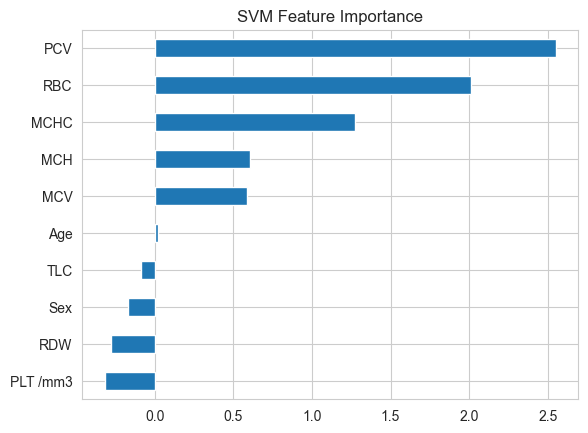

In [99]:
coef.sort_values().plot(kind="barh")
plt.title("SVM Feature Importance")
plt.show()

## Model deployment

In [101]:
import joblib

artifact = {
    "model": model_svc,
    "scaler": scaler,
    "label_encoder": le,
    "feature_names": X_cols
}

joblib.dump(artifact, "anemia_model.pkl")

print("Model saved")

Model saved
